Detected exogenous columns: ['Min price in KG', 'Max price in KG', 'ALLSKY_SFC_SW_DWN', 'T2M', 'PRECTOTCORR', 'WS2M', 'GWETTOP', 'T2M_MAX', 'T2M_MIN', 'RH2M']
Using weather/environment exogenous features for hybrid model.
ADF p-value: 0.0000
Using d = 0 for differencing based on ADF test.
Fitting SARIMAX(order=(2, 0, 2), seasonal_order=(1, 0, 1, 7)) ...
Model fitted.


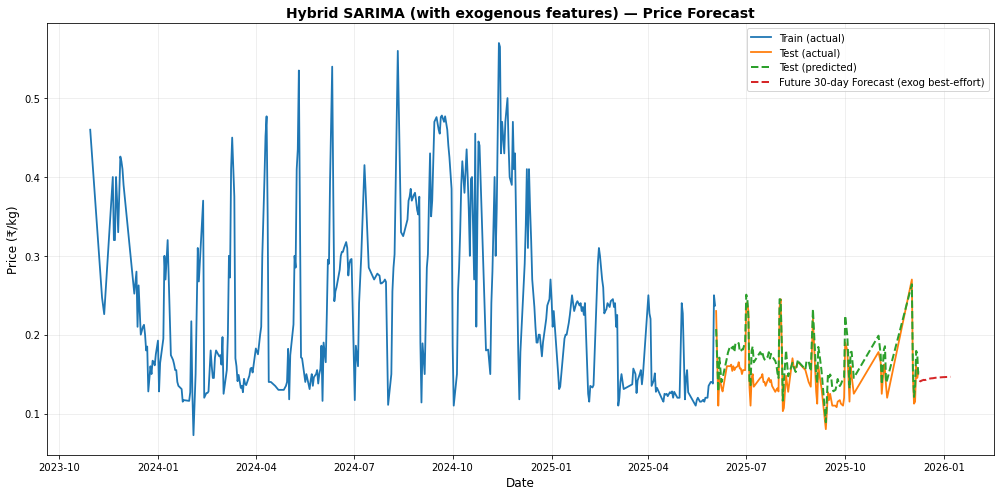


Model performance on test set:
MAE : 0.0210
RMSE: 0.0233
MAPE: 15.20%

Future 30 day forecast (first 10 shown):
Day 1 (2025-12-09): ₹0.14/kg
Day 2 (2025-12-10): ₹0.14/kg
Day 3 (2025-12-11): ₹0.14/kg
Day 4 (2025-12-12): ₹0.14/kg
Day 5 (2025-12-13): ₹0.14/kg
Day 6 (2025-12-14): ₹0.14/kg
Day 7 (2025-12-15): ₹0.14/kg
Day 8 (2025-12-16): ₹0.14/kg
Day 9 (2025-12-17): ₹0.14/kg
Day 10 (2025-12-18): ₹0.14/kg

Notes:
- Hybrid model used the columns: ['Min price in KG', 'Max price in KG', 'ALLSKY_SFC_SW_DWN', 'T2M', 'PRECTOTCORR', 'WS2M', 'GWETTOP', 'T2M_MAX', 'T2M_MIN', 'RH2M']
- For best accuracy, provide a real forecast file of exogenous variables for the future (e.g., 30-day NASA or weather forecast).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Step 1st Load Data 
df1 = pd.read_csv(r'C:\Users\mayank\OneDrive\Desktop\Prediction\Lasalgaon.csv')
df2 = pd.read_csv(r'C:\Users\mayank\Downloads\Nasa.csv')

date_col1 = 'DATE'            
price_col = 'Modal Price in KG'  
date_col2 = df2.columns[0]    

df1[date_col1] = pd.to_datetime(df1[date_col1])
df2[date_col2] = pd.to_datetime(df2[date_col2])
df2.rename(columns={date_col2: date_col1}, inplace=True)

# step 2 merge data

df = pd.merge(df1, df2, on=date_col1, how='outer').sort_values(date_col1)

df = df[~df[date_col1].duplicated(keep='first')]

df.fillna(method='ffill', inplace=True)   
df.set_index(date_col1, inplace=True)

if price_col not in df.columns:
    raise ValueError(f"Price column '{price_col}' not found in merged dataframe. Check column name.")
    
# step 3 Select exogenous variables

exog_candidates = df.select_dtypes(include=[np.number]).columns.tolist()
exog_cols = [c for c in exog_candidates if c != price_col]

print(f"Detected exogenous columns: {exog_cols}")

use_exog = len(exog_cols) > 0

# step 4 Feature engineering

df['ma7'] = df[price_col].rolling(7).mean()
df['ma30'] = df[price_col].rolling(30).mean()
df['change'] = df[price_col].diff()
df.dropna(inplace=True) 

if use_exog:
    print("Using weather/environment exogenous features for hybrid model.")
else:
    print("No exogenous numeric columns found — running pure SARIMA (still hybrid-ready).")

# 5 Scale target and exogenous (helps optimizer & stability)

price_scaler = StandardScaler()
df['scaled_price'] = price_scaler.fit_transform(df[[price_col]])

if use_exog:
    exog_scaler = StandardScaler()
    df_exog = pd.DataFrame(exog_scaler.fit_transform(df[exog_cols]), 
                           index=df.index, columns=exog_cols)
else:
    df_exog = None

# step 6 Train/test split ----------
split_idx = int(len(df) * 0.8)
train_y = df['scaled_price'].iloc[:split_idx]
test_y = df['scaled_price'].iloc[split_idx:]

if use_exog:
    train_exog = df_exog.iloc[:split_idx]
    test_exog = df_exog.iloc[split_idx:]
else:
    train_exog = None
    test_exog = None

# step 7 Stationarity and differencing

adf_result = adfuller(train_y)
print(f"ADF p-value: {adf_result[1]:.4f}")
d = 0 if adf_result[1] < 0.05 else 1
print(f"Using d = {d} for differencing based on ADF test.")

# step 8 Fit SARIMAX with exog (hybrid)
order = (2, d, 2)
seasonal_order = (1, 0, 1, 7)  # weekly 

if use_exog:
    model = SARIMAX(train_y, order=order, seasonal_order=seasonal_order, exog=train_exog)
else:
    model = SARIMAX(train_y, order=order, seasonal_order=seasonal_order)

print(f"Fitting SARIMAX(order={order}, seasonal_order={seasonal_order}) ...")
fitted = model.fit(disp=False)
print("Model fitted.")

# step 9 Forecast on test set using proper exog 
if use_exog:
    pred_test_res = fitted.get_forecast(steps=len(test_y), exog=test_exog)
else:
    pred_test_res = fitted.get_forecast(steps=len(test_y))

test_pred_scaled = pred_test_res.predicted_mean

# step 10 Future exog handling (best-effort)
future_steps = 30
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

if use_exog:
    last_exog = df_exog.iloc[-1]

    future_exog = pd.DataFrame([last_exog.values] * future_steps, index=future_dates, columns=exog_cols)
     
else:
    future_exog = None

# Forecast for future_steps (you may also forecast test+future in one go)
if use_exog:
    pred_future_res = fitted.get_forecast(steps=future_steps, exog=future_exog)
else:
    pred_future_res = fitted.get_forecast(steps=future_steps)

future_pred_scaled = pred_future_res.predicted_mean

# step 11  Inverse scaling to original price units 
test_pred = price_scaler.inverse_transform(test_pred_scaled.values.reshape(-1, 1)).ravel()
future_pred = price_scaler.inverse_transform(future_pred_scaled.values.reshape(-1, 1)).ravel()
actual_test_prices = df[price_col].loc[test_y.index].values

# step 12. Plot results
plt.figure(figsize=(14, 7))

train_actual_prices = df[price_col].loc[train_y.index].values
test_actual_prices = df[price_col].loc[test_y.index].values

plt.plot(train_y.index, train_actual_prices, label='Train (actual)', linewidth=1.8)
plt.plot(test_y.index, test_actual_prices, label='Test (actual)', linewidth=1.8)
plt.plot(test_y.index, test_pred, label='Test (predicted)', linestyle='--', linewidth=2)

plt.plot(future_dates, future_pred, label=f'Future {future_steps}-day Forecast (exog best-effort)', 
         linestyle='--', linewidth=2)
plt.title('Hybrid SARIMA (with exogenous features) — Price Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹/kg)', fontsize=12)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# step 13 Performance metrics 

mae = mean_absolute_error(actual_test_prices, test_pred)
rmse = np.sqrt(mean_squared_error(actual_test_prices, test_pred))
mape = np.mean(np.abs((actual_test_prices - test_pred) / actual_test_prices)) * 100

print("\nModel performance on test set:")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# step 14  Print sample future values ----------
print(f"\nFuture {future_steps} day forecast (first 10 shown):")
for i, (d, p) in enumerate(zip(future_dates[:10], future_pred[:10]), 1):
    print(f"Day {i} ({d.date()}): ₹{p:.2f}/kg")
    
print("\nNotes:")
if use_exog:
    print("- Hybrid model used the columns:", exog_cols)
    print("- For best accuracy, provide a real forecast file of exogenous variables for the future (e.g., 30-day NASA or weather forecast).")
else:
    print("- No exogenous numeric columns detected; the model ran as univariate SARIMA.")
    print("- To gain hybrid benefits, ensure your NASA file contains numeric predictors (temperature, precipitation, humidity, solar radiation, etc).")


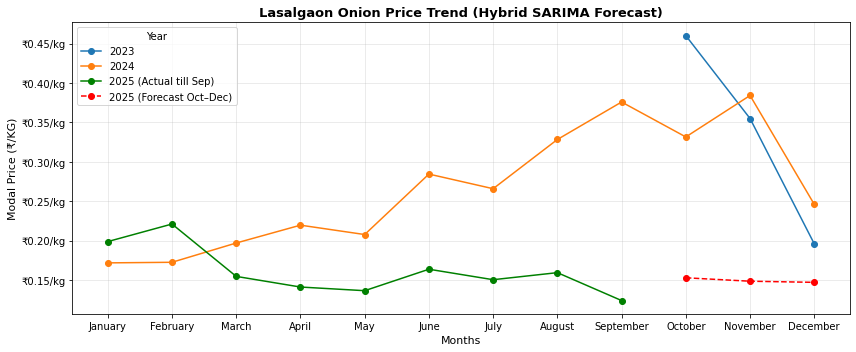

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure DATE column is available
df_plot = df.reset_index().rename(columns={df.index.name or 'index': 'DATE'})
df_plot['Year'] = df_plot['DATE'].dt.year
df_plot['Month'] = df_plot['DATE'].dt.strftime('%B')

# Forecast data (from Hybrid SARIMA model)
future_df = pd.DataFrame({
    'DATE': future_dates,
    'Modal Price in KG': future_pred,
    'Year': 2025,
    'Month': future_dates.strftime('%B')
})

# Combine both (actual + forecast)
combined = pd.concat([df_plot, future_df], ignore_index=True)

# Group by month to get monthly average
combined['Month'] = pd.Categorical(
    combined['Month'],
    categories=['January','February','March','April','May','June','July','August',
                'September','October','November','December'],
    ordered=True
)
monthly_avg = combined.groupby(['Year', 'Month'], as_index=False)['Modal Price in KG'].mean()


plt.figure(figsize=(12,5))

# Plot each year's line
for year, color in zip([2023, 2024], ['cornflowerblue', 'darkorange']):
    subset = monthly_avg[monthly_avg['Year'] == year]
    plt.plot(subset['Month'], subset['Modal Price in KG'], marker='o', label=str(year))

# 2025 actual till Sep
actual_2025 = monthly_avg[(monthly_avg['Year']==2025) & (monthly_avg['Month'].isin(['January','February','March','April','May','June','July','August','September']))]
plt.plot(actual_2025['Month'], actual_2025['Modal Price in KG'],
         marker='o', color='green', label='2025 (Actual till Sep)')

# 2025 forecast Oct–Dec
forecast_2025 = monthly_avg[(monthly_avg['Year']==2025) & (monthly_avg['Month'].isin(['October','November','December']))]
plt.plot(forecast_2025['Month'], forecast_2025['Modal Price in KG'],
         marker='o', color='red', linestyle='--', label='2025 (Forecast Oct–Dec)')

# Labels & Styling 
plt.title('Lasalgaon Onion Price Trend (Hybrid SARIMA Forecast)', fontsize=13, fontweight='bold')
plt.xlabel('Months', fontsize=11)
plt.ylabel('Modal Price (₹/KG)', fontsize=11)
plt.legend(title='Year')
plt.grid(alpha=0.3)

# Add ₹/kg format on y-axis
ax = plt.gca()
ax.set_yticklabels([f'₹{y:.2f}/kg' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()



